In [44]:
import pandas as pd
import numpy as np
import bilby
import pickle

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import seaborn as sns
from matplotlib import rcParams
import corner

In [45]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import icarogw

In [3]:
rcParams['text.usetex'] = True
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Palatino Linotype', 'Palatino', 'TeX Gyre Pagella', 'Times New Roman']
rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'Palatino'
rcParams['mathtext.it'] = 'Palatino:italic'
rcParams['mathtext.bf'] = 'Palatino:bold'

In [4]:
matplotlib.rc('xtick', labelsize = 24) 
matplotlib.rc('ytick', labelsize = 24)

In [5]:
my_color = '#2f4f4f'
my_color2 = '#f6b26b'

In [6]:
default_kwargs = dict(
            bins=50, smooth=0.9,
            smooth1d=0.8,
            show_titles=False,
            title_kwargs=dict(fontsize=19),
            title_fmt='.2f',
            title_quantiles=[0.16,0.5,0.84],
            label_kwargs = dict(color = 'black', fontsize = 23),
            truth_color='black', 
            levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
            plot_density=False, plot_datapoints=False, fill_contours=True,
            max_n_ticks=3, labelpad=0.05
            )

In [85]:
path_to_plots = 'plots/'

In [52]:
injected_values_vanilla = {'H0':67.8, 
                   'Om0':0.3, 
                   'alpha':3.4, 
                   'beta':0.8, 
                   'mmin':5, 
                   'mmax':100, 
                   'delta_m':4.8, 
                   'mu_g':35, 
                   'sigma_g':3.9, 
                   'lambda_peak':0.04, 
                   'gamma':2.7, 
                   'kappa':2.9, 
                   'zp':1.9,
                   'R0':20}

injected_values_redshift = {'H0':173.28, 
                   'Om0':0.3, 
                   'alpha':5.325, 
                   'beta':3.05, 
                   'mmin':7.8, 
                   'mmax':87.58, 
                   'delta_m':3.19, 
                   'mu_g':40.9, 
                   'sigma_g':7.63, 
                   'lambda_peak':0.04, 
                   'gamma':0.03, 
                   'kappa':2.92, 
                   'zp':3.86,
                   'R0':16.1}

In [53]:
columns_lbs = ['H0', 'Om0', 'alpha', 'beta', 'mmin', 'mmax', 'delta_m', 'mu_g', 'sigma_g', 'lambda_peak',
               'gamma', 'kappa', 'zp', 'R0']

## Redshift-dependent case

In [10]:
# load dictionary of events
case2_dictionary_path = '/home/ulyana.dupletsa/MDC-Paper1/data/case2_events_dictionary.pkl'
with open(case2_dictionary_path, 'rb') as f:
    case2_dict = pickle.load(f)

In [11]:
case2_test_data = bilby.core.result.read_in_result(case2_dict['case2_inj_number']['case2_1e6inj_80ev'])
case2_test_data_posteriors = case2_test_data.posterior[columns_lbs]

### Rate plots

In [14]:
def z_dependent_rate(zz, R0, gamma, zp, kappa):
    return R0*(1+zz)**gamma*(1+(1+zp)**(-(gamma+kappa)))/(1+((1+zz)/(1+zp))**(gamma+kappa))

In [15]:
n_samples = 50

In [16]:
zz = np.linspace(0.0001, 2, n_samples)

In [17]:
R0 = injected_values_redshift['R0']
gamma = injected_values_redshift['gamma']
kappa = injected_values_redshift['kappa']
zp = injected_values_redshift['zp']

In [18]:
rate_params = ['R0', 'gamma', 'zp', 'kappa']
rate_params_lbs = ['$\gamma$', 
              '$\kappa$', 
              '$z_{\\rm p}$', 
              '$R_0$']

In [19]:
rate_posteriors = case2_test_data_posteriors[rate_params]

## Estimate the highest density region (at 68%)

In [8]:
from sklearn.neighbors import KernelDensity

In [21]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(rate_posteriors)

### Check the kde interpolation went well

In [45]:
np.random.seed(42)
kde_df = kde.sample(n_samples=len(rate_posteriors))

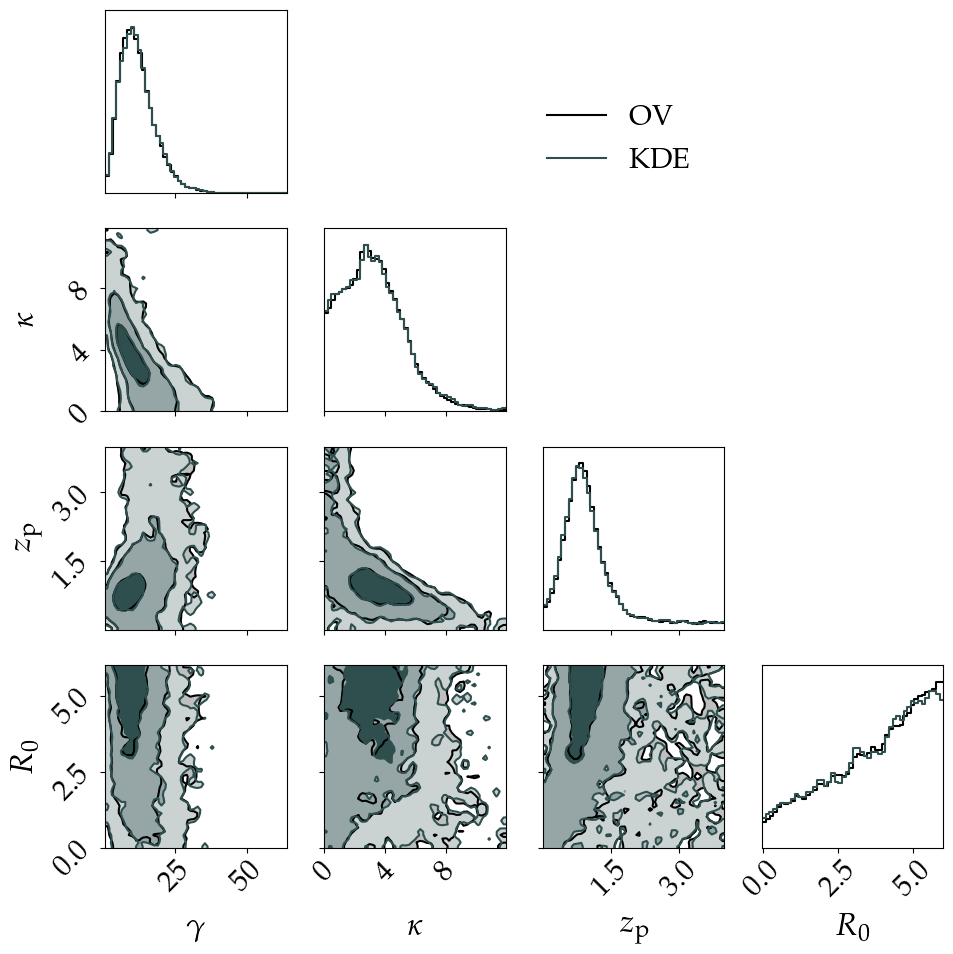

In [46]:
# compare corner plots as well
figure = corner.corner(rate_posteriors[rate_params], color = 'black', **default_kwargs)
corner.corner(kde_df, labels=rate_params_lbs, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.65, 0.85), fontsize = 21, frameon=False)
plt.tight_layout()
plt.show()

In [47]:
log_density = kde.score_samples(rate_posteriors)
density = np.exp(log_density)

In [48]:
rate_posteriors['density'] = density

/tmp/ipykernel_2145959/833251895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rate_posteriors['density'] = density


In [49]:
df_sorted = rate_posteriors.sort_values('density', ascending=False)

In [50]:
df_sorted['cumulative_density'] = df_sorted['density'].cumsum()
total_density = df_sorted['density'].sum()
cutoff_density = 0.68 * total_density

In [51]:
df_hdi = df_sorted[df_sorted['cumulative_density'] <= cutoff_density]

In [ ]:
from tqdm import tqdm

100%|██████████| 4532/4532 [03:20<00:00, 22.58it/s]


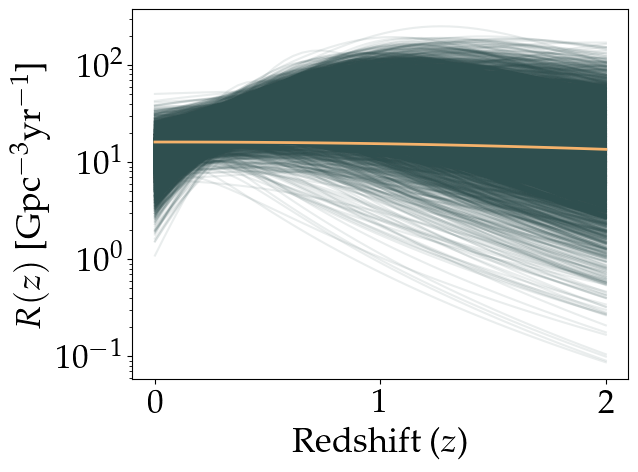

In [53]:
n_posterior_samples = len(df_hdi)

fig, ax = plt.subplots()

for i in tqdm(range(n_posterior_samples)):
    R0_sample = df_hdi['R0'].iloc[i]
    gamma_sample = df_hdi['gamma'].iloc[i]
    zp_sample = df_hdi['zp'].iloc[i]
    kappa_sample = df_hdi['kappa'].iloc[i]
    sns.lineplot(x = zz, y = z_dependent_rate(zz, R0_sample, gamma_sample, zp_sample, kappa_sample),
             color=my_color, alpha=0.1)
    
sns.lineplot(x = zz, y = z_dependent_rate(zz, R0, gamma, zp, kappa), color=my_color2,
         linewidth=2)
plt.xlabel('Redshift ($z$)', fontsize = 25)
plt.ylabel('$R(z)$ [Gpc$^{-3}$yr$^{-1}$]', fontsize = 25) 
plt.yscale('log')
plt.savefig(path_to_plots + '/' + 'redshift_rate_samples_hdi.pdf', bbox_inches='tight')
plt.show()

### Mass Plots

In [22]:
mm = np.linspace(10, 85, n_samples)

In [29]:
def alpha_z_inj(z):
    return 5.325+2.99*z
def beta_z_inj(z):
    return 3.05-1.063*z
def mmin_z_inj(z):
    return 7.8+0.324*z
def mmax_z_inj(z):
    return 87.58+17.16*z
def mu_g_z_inj(z):
    return 40.9+2.84*z
def sigma_g_z_inj(z):
    return 7.63+2.70*z
def lambda_peak_z_inj(z):
    return 0.04+0.43*z
def delta_m_z():
    return 3.19

In [30]:
import scipy.stats
import scipy

In [25]:
zz_samples= [0., 0.32, 0.85, 1.32]

In [26]:
shade0 = '#abb8b8'
shade1 = '#829595'
shade2 = '#587272'
shade3 = '#1c2f2f'

In [27]:
my_colors = [shade1, shade2, shade3]

In [11]:
red_mass_params = ['alpha', 'beta', 'mmin', 'mmax', 'delta_m', 'mu_g', 'sigma_g', 'lambda_peak']
red_mass_params_lbs = ['$\\alpha$', 
              '$\\beta$', 
              '$m_{\\rm min}$', 
              '$m_{\\rm max}$', 
              '$\\delta m$', 
              '$\\mu_{\\rm g}$', 
              '$\\sigma_{\\rm g}$', 
              '$\\lambda_{\\rm peak}$'
              ]

In [29]:
path_to_zbin1 = case2_dict['case2_zbin']['case2_1e5inj_zbin1']
zbin1_pe = bilby.core.result.read_in_result(path_to_zbin1).posterior
zbin1_pe_sel = zbin1_pe[red_mass_params]

path_to_zbin2 = case2_dict['case2_zbin']['case2_1e5inj_zbin2']
zbin2_pe = bilby.core.result.read_in_result(path_to_zbin2).posterior
zbin2_pe_sel = zbin2_pe[red_mass_params]

path_to_zbin3 = case2_dict['case2_zbin']['case2_1e5inj_zbin3']
zbin3_pe = bilby.core.result.read_in_result(path_to_zbin3).posterior
zbin3_pe_sel = zbin3_pe[red_mass_params]

## kde estimates

In [30]:
kde_bin1 = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(zbin1_pe_sel)

In [31]:
np.random.seed(42)
kde_df_bin1 = kde_bin1.sample(n_samples=len(zbin1_pe_sel))

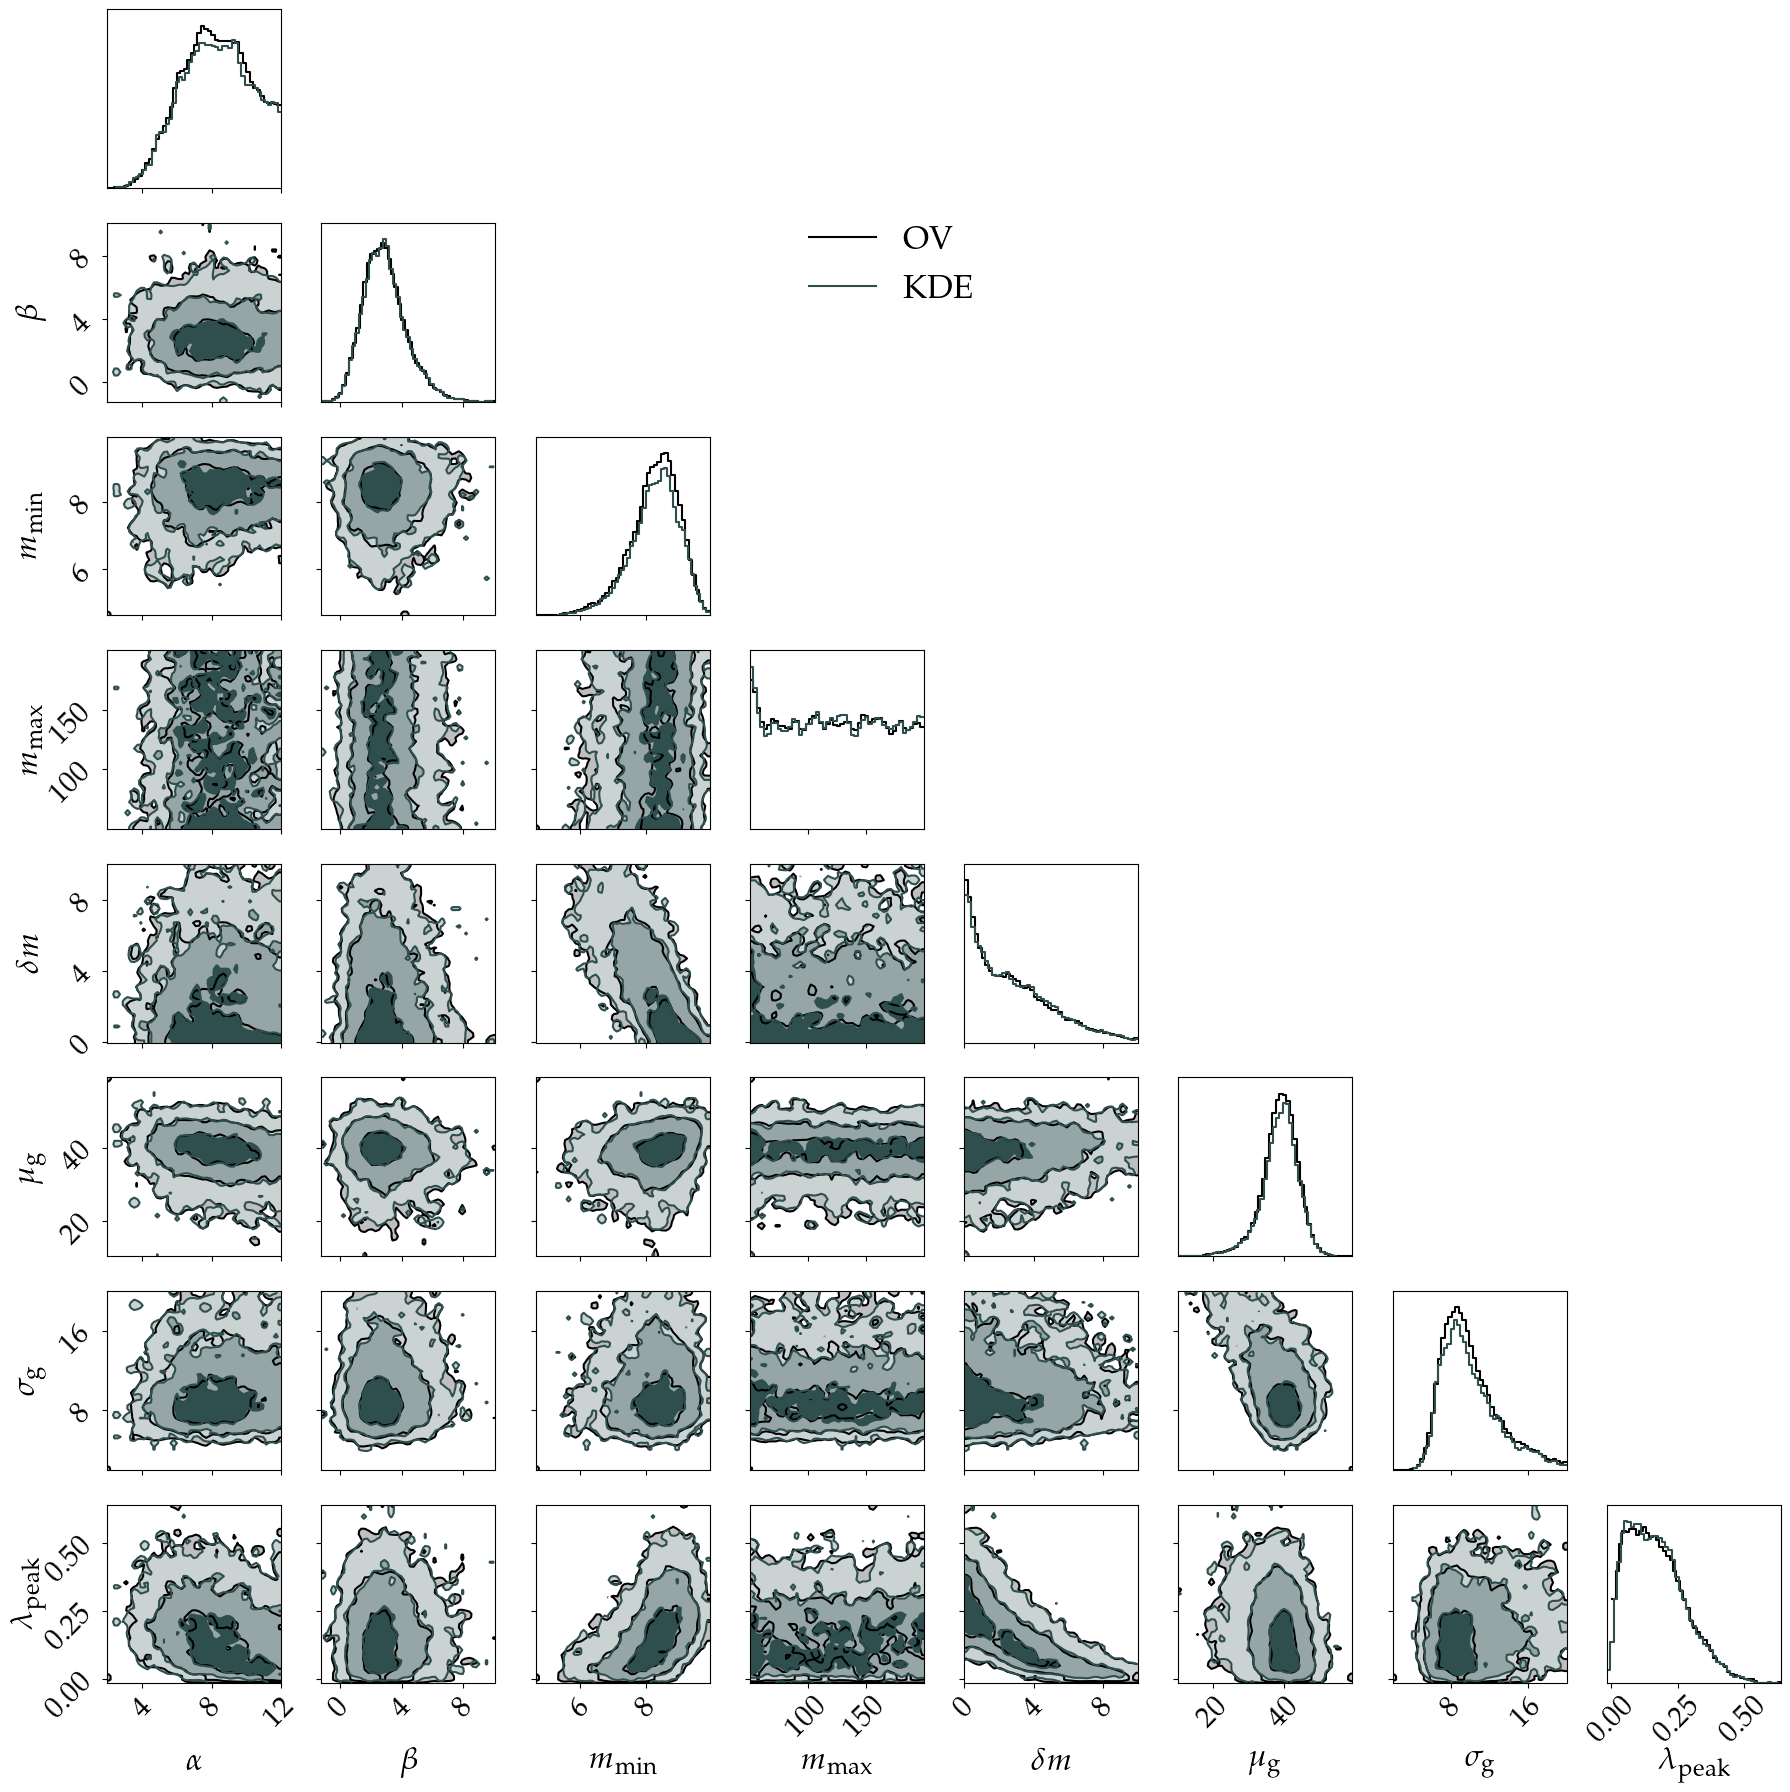

In [32]:
# compare corner plots as well
figure = corner.corner(zbin1_pe_sel[red_mass_params], color = 'black', **default_kwargs)
corner.corner(kde_df_bin1, labels=red_mass_params_lbs, color = my_color, fig = figure,  **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.5, 0.85), fontsize = 24, frameon=False)
plt.tight_layout()
plt.show()

In [33]:
log_density = kde_bin1.score_samples(zbin1_pe_sel)
density = np.exp(log_density)
zbin1_pe_sel['density'] = density
df_bin1_sorted = zbin1_pe_sel.sort_values('density', ascending=False)
df_bin1_sorted['cumulative_density'] = df_bin1_sorted['density'].cumsum()
total_density = df_bin1_sorted['density'].sum()
cutoff_density = 0.68 * total_density
df_hdi_bin1 = df_bin1_sorted[df_bin1_sorted['cumulative_density'] <= cutoff_density]

/tmp/ipykernel_2931116/3538054733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zbin1_pe_sel['density'] = density


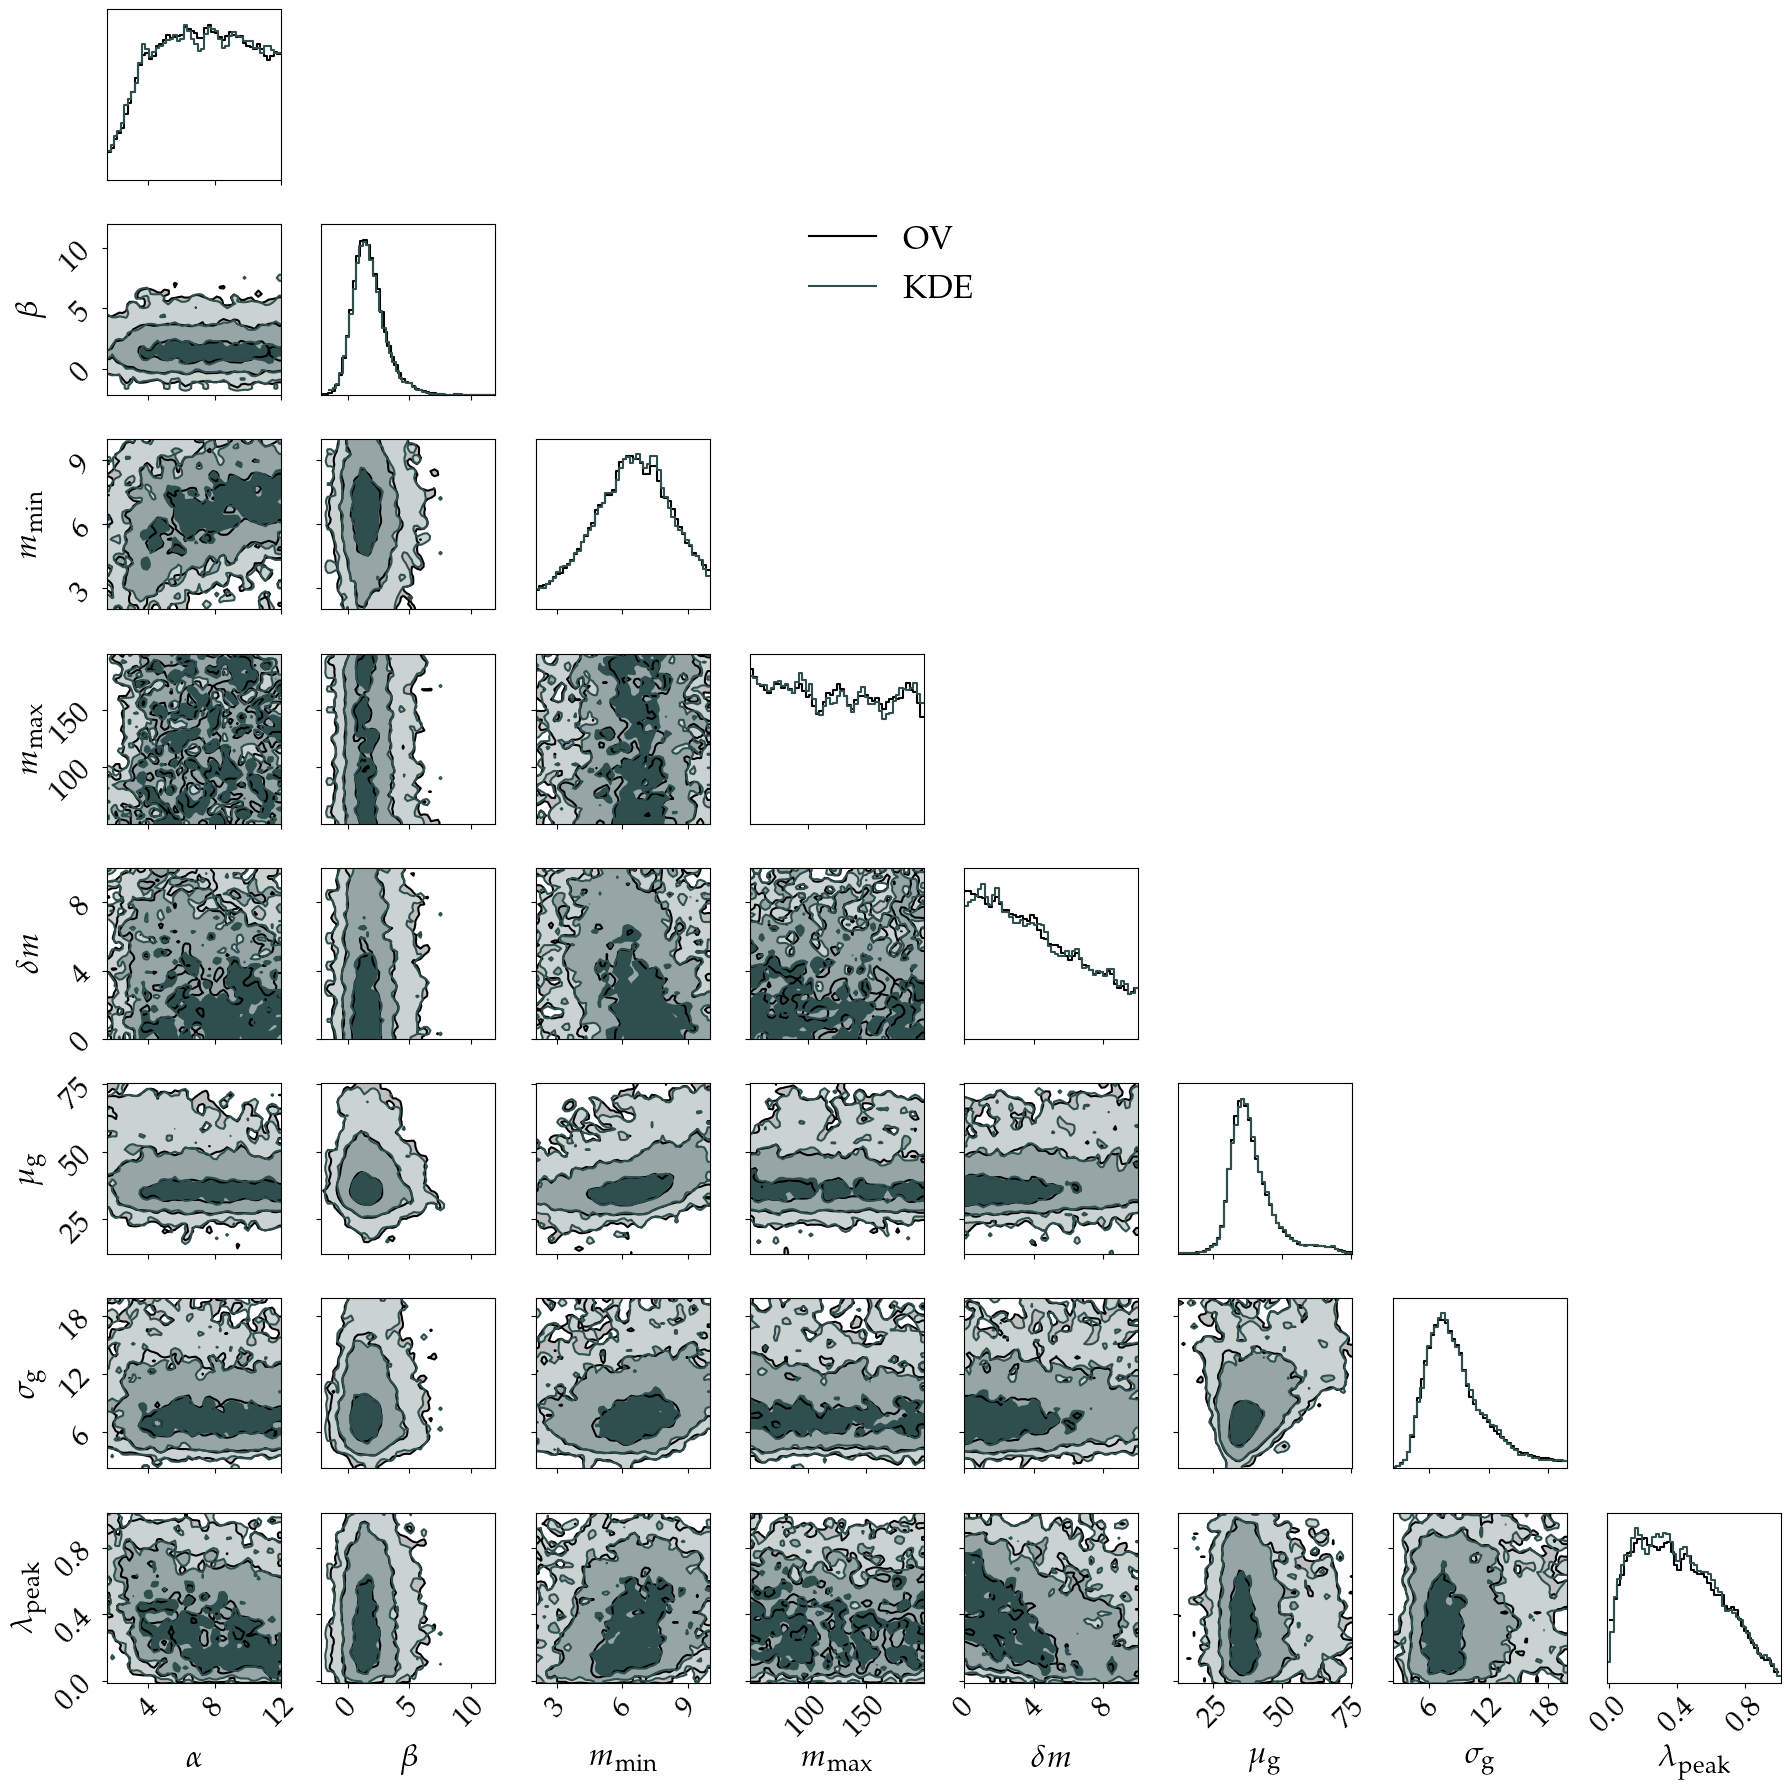

/tmp/ipykernel_2931116/4169313074.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zbin2_pe_sel['density'] = density


In [34]:
kde_bin2 = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(zbin2_pe_sel)

np.random.seed(42)
kde_df_bin2 = kde_bin2.sample(n_samples=len(zbin2_pe_sel))

# compare corner plots as well
figure = corner.corner(zbin2_pe_sel[red_mass_params], color = 'black', **default_kwargs)
corner.corner(kde_df_bin2, labels=red_mass_params_lbs, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.5, 0.85), fontsize = 24, frameon=False)
plt.tight_layout()
plt.show()

log_density = kde_bin2.score_samples(zbin2_pe_sel)
density = np.exp(log_density)
zbin2_pe_sel['density'] = density
df_bin2_sorted = zbin2_pe_sel.sort_values('density', ascending=False)
df_bin2_sorted['cumulative_density'] = df_bin2_sorted['density'].cumsum()
total_density = df_bin2_sorted['density'].sum()
cutoff_density = 0.68 * total_density
df_hdi_bin2 = df_bin2_sorted[df_bin2_sorted['cumulative_density'] <= cutoff_density]

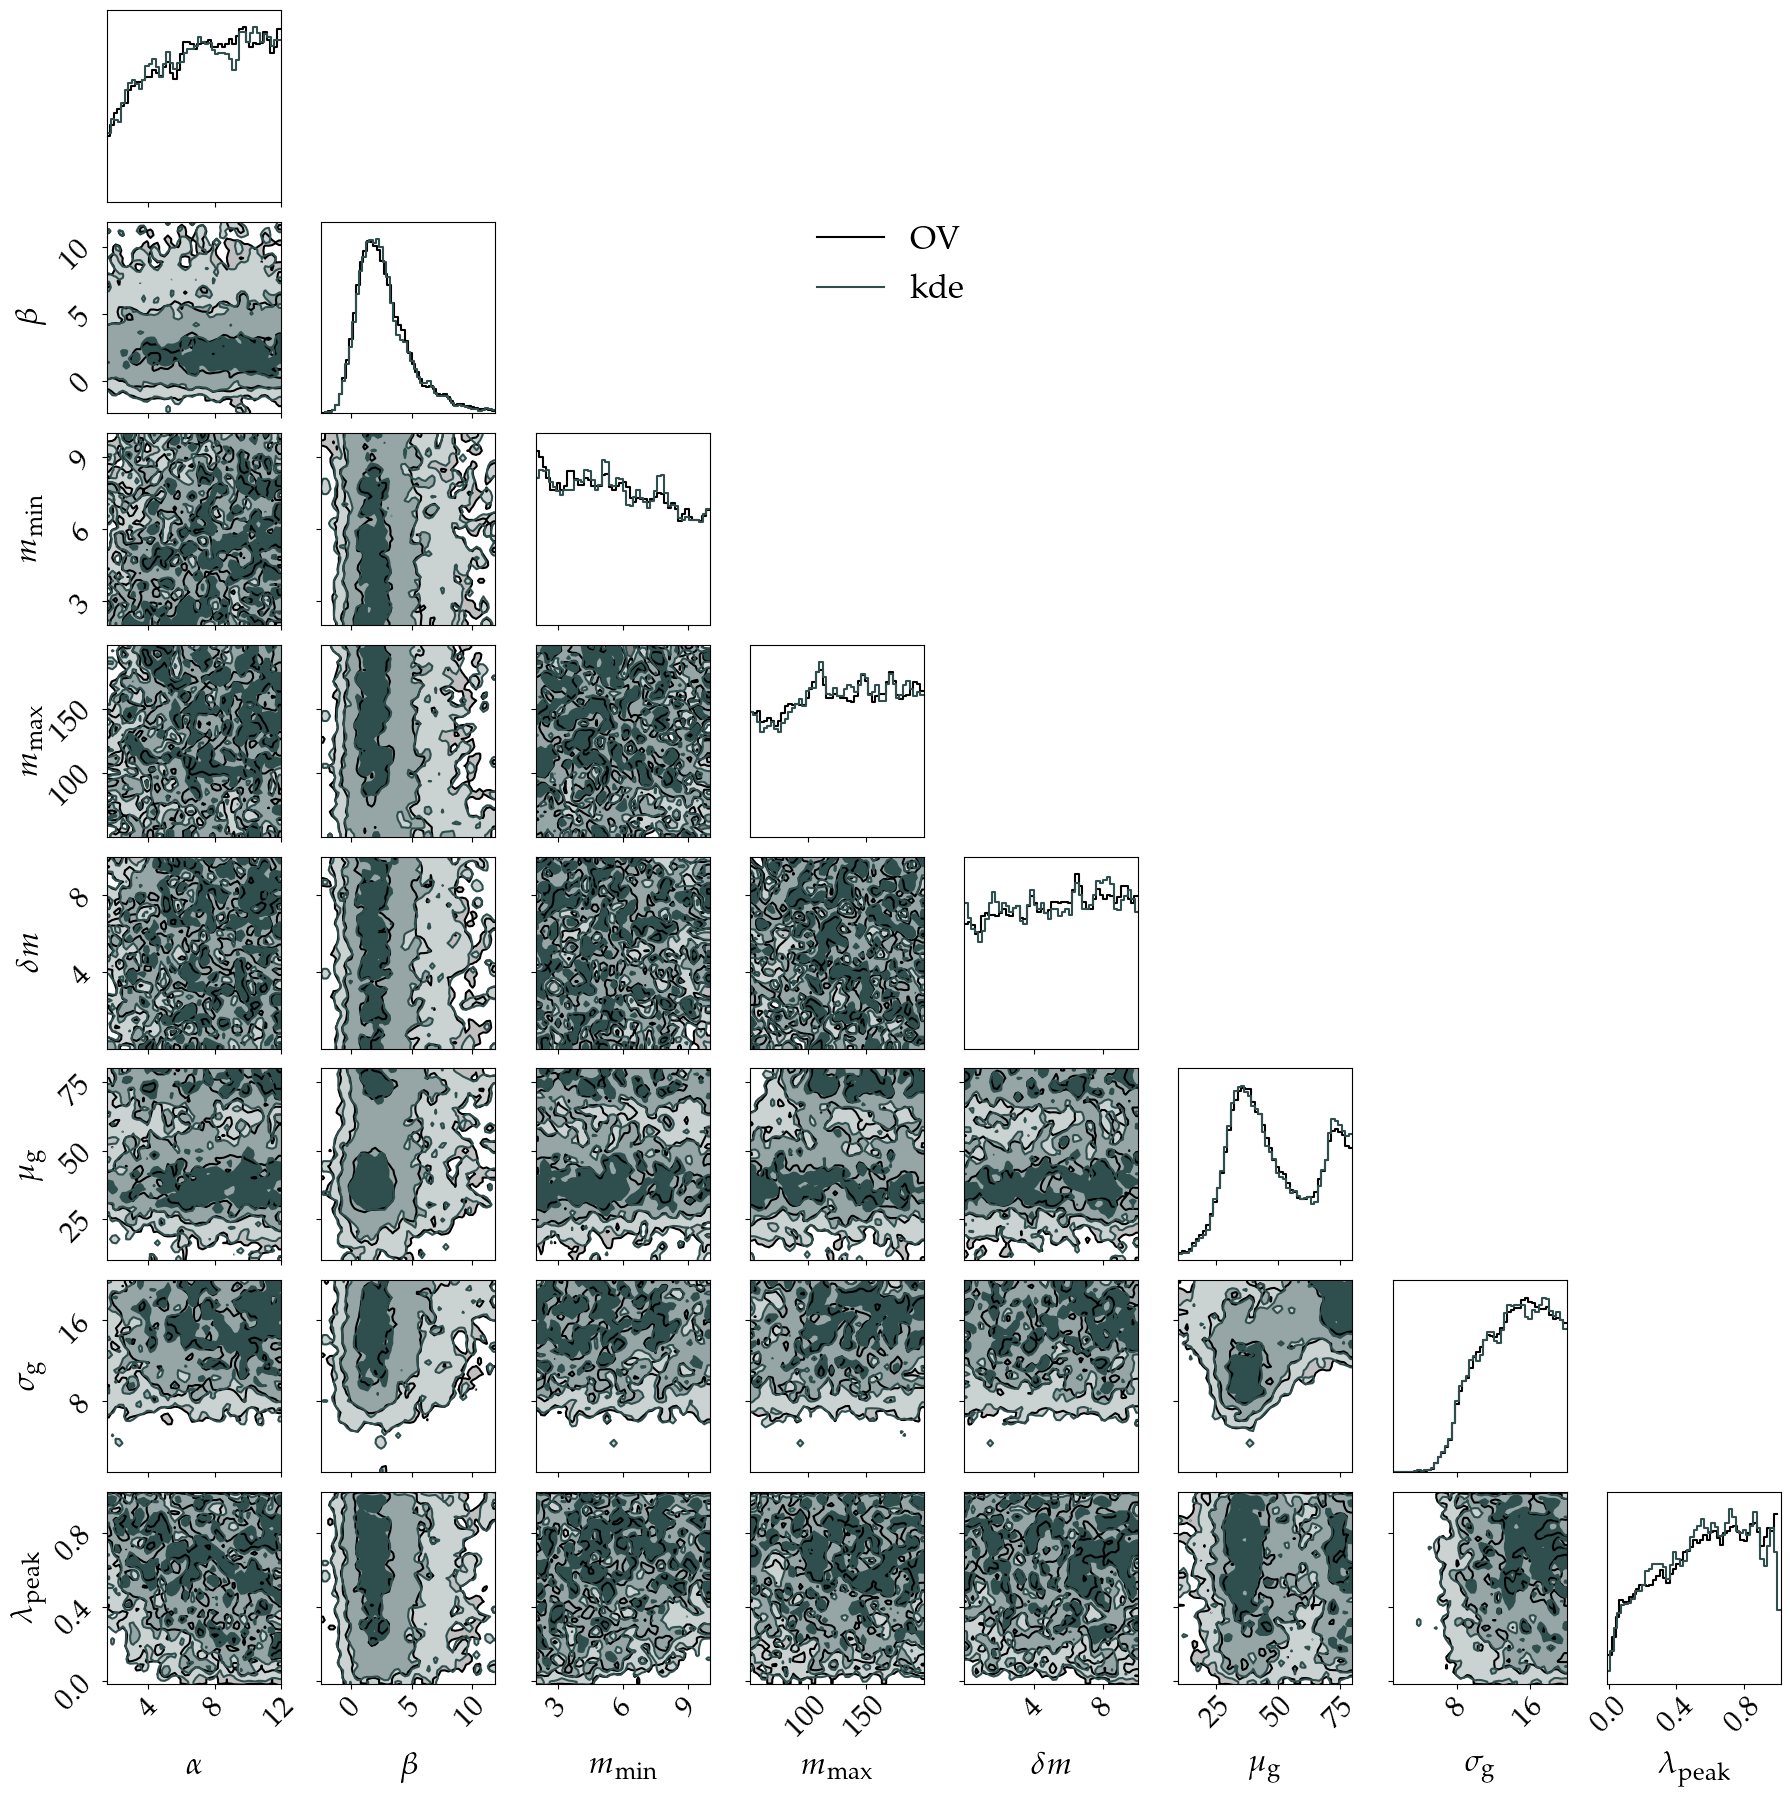

/tmp/ipykernel_2931116/4084119028.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zbin3_pe_sel['density'] = density


In [35]:
kde_bin3 = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(zbin3_pe_sel)

np.random.seed(42)
kde_df_bin3 = kde_bin3.sample(n_samples=len(zbin3_pe_sel))

# compare corner plots as well
figure = corner.corner(zbin3_pe_sel[red_mass_params], color = 'black', **default_kwargs)
corner.corner(kde_df_bin3, labels=red_mass_params_lbs, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'kde'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.5, 0.85), fontsize = 24, frameon=False)
plt.tight_layout()
plt.show()

log_density = kde_bin3.score_samples(zbin3_pe_sel)
density = np.exp(log_density)
zbin3_pe_sel['density'] = density
df_bin3_sorted = zbin3_pe_sel.sort_values('density', ascending=False)
df_bin3_sorted['cumulative_density'] = df_bin3_sorted['density'].cumsum()
total_density = df_bin3_sorted['density'].sum()
cutoff_density = 0.68 * total_density
df_hdi_bin3 = df_bin3_sorted[df_bin3_sorted['cumulative_density'] <= cutoff_density]

In [36]:
warnings.filterwarnings("ignore")

In [91]:
mm = np.linspace(8, 85, 50)
M1, M2 = np.meshgrid(mm,mm)

In [92]:
mass_wrap = icarogw.wrappers.massprior_PowerLawPeak()
mass_wrap=icarogw.wrappers.m1m2_conditioned_lowpass(mass_wrap)


n_posterior_samples_bin1 = len(df_hdi_bin1)
m1_prob_bin1, m2_prob_bin1  = np.zeros((n_posterior_samples_bin1, len(mm))), np.zeros((n_posterior_samples_bin1, len(mm)))

n_posterior_samples_bin2 = len(df_hdi_bin2)
m1_prob_bin2, m2_prob_bin2  = np.zeros((n_posterior_samples_bin2, len(mm))), np.zeros((n_posterior_samples_bin2, len(mm)))

n_posterior_samples_bin3 = len(df_hdi_bin3)
m1_prob_bin3, m2_prob_bin3 = np.zeros((n_posterior_samples_bin3, len(mm))), np.zeros((n_posterior_samples_bin3, len(mm)))

100%|██████████| 3358/3358 [15:22<00:00,  3.64it/s]
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


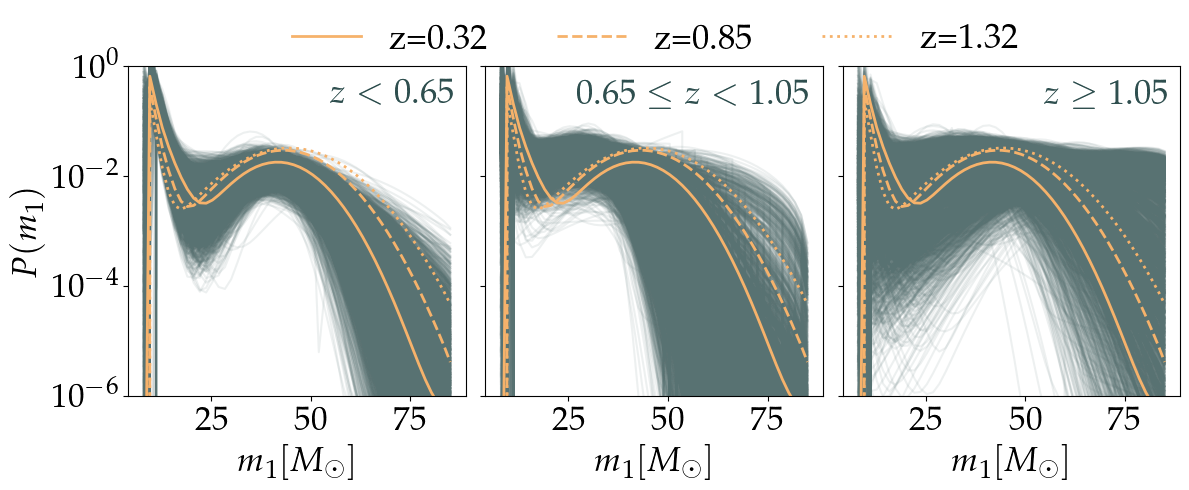

In [95]:
fig, ax = plt.subplots(1, 3, sharey=True, figsize=(12, 4.5))

for i in tqdm(range(n_posterior_samples_bin1)):
    alpha = df_hdi_bin1['alpha'].iloc[i]
    beta = df_hdi_bin1['beta'].iloc[i]
    mmin = df_hdi_bin1['mmin'].iloc[i]
    mmax = df_hdi_bin1['mmax'].iloc[i]
    delta_m = df_hdi_bin1['delta_m'].iloc[i]
    mu_g = df_hdi_bin1['mu_g'].iloc[i]
    sigma_g = df_hdi_bin1['sigma_g'].iloc[i]
    lambda_peak = df_hdi_bin1['lambda_peak'].iloc[i]
    
    mass_wrap.update(**{'alpha':alpha,'beta':beta,'mmin':mmin,'mmax':mmax,'delta_m':delta_m,'mu_g':mu_g,'sigma_g':sigma_g,'lambda_peak':lambda_peak})
    pdf=mass_wrap.pdf(M1,M2)
    
    m1_prob_bin1[i, :] = np.trapz(pdf,mm,axis=0)
    m2_prob_bin1[i, :] = np.trapz(pdf,mm,axis=1)
    
    sns.lineplot(x = mm, y = m1_prob_bin1[i, :], color=shade2, alpha=0.1, ax = ax[0])


for i in tqdm(range(n_posterior_samples_bin2)):
    alpha = df_hdi_bin2['alpha'].iloc[i]
    beta = df_hdi_bin2['beta'].iloc[i]
    mmin = df_hdi_bin2['mmin'].iloc[i]
    mmax = df_hdi_bin2['mmax'].iloc[i]
    delta_m = df_hdi_bin2['delta_m'].iloc[i]
    mu_g = df_hdi_bin2['mu_g'].iloc[i]
    sigma_g = df_hdi_bin2['sigma_g'].iloc[i]
    lambda_peak = df_hdi_bin2['lambda_peak'].iloc[i]
    mass_wrap.update(**{'alpha':alpha,'beta':beta,'mmin':mmin,'mmax':mmax,'delta_m':delta_m,'mu_g':mu_g,'sigma_g':sigma_g,'lambda_peak':lambda_peak})
    pdf=mass_wrap.pdf(M1,M2)
    
    m1_prob_bin2[i, :] = np.trapz(pdf,mm,axis=0)
    m2_prob_bin2[i, :] = np.trapz(pdf,mm,axis=1)
    
    sns.lineplot(x = mm, y = m2_prob_bin2[i, :], color=shade2, alpha=0.1, ax = ax[1])
    
for i in tqdm(range(n_posterior_samples_bin3)):
    alpha = df_hdi_bin3['alpha'].iloc[i]
    beta = df_hdi_bin3['beta'].iloc[i]
    mmin = df_hdi_bin3['mmin'].iloc[i]
    mmax = df_hdi_bin3['mmax'].iloc[i]
    delta_m = df_hdi_bin3['delta_m'].iloc[i]
    mu_g = df_hdi_bin3['mu_g'].iloc[i]
    sigma_g = df_hdi_bin3['sigma_g'].iloc[i]
    lambda_peak = df_hdi_bin3['lambda_peak'].iloc[i]
    mass_wrap.update(**{'alpha':alpha,'beta':beta,'mmin':mmin,'mmax':mmax,'delta_m':delta_m,'mu_g':mu_g,'sigma_g':sigma_g,'lambda_peak':lambda_peak})
    pdf=mass_wrap.pdf(M1,M2)
    
    m1_prob_bin3[i, :] = np.trapz(pdf,mm,axis=0)
    m2_prob_bin3[i, :] = np.trapz(pdf,mm,axis=1)
    
    sns.lineplot(x = mm, y = m1_prob_bin3[i, :], color=shade2, alpha=0.1, ax = ax[2])
    
    
    
mirror_lbs = ['$z<0.65$', '$0.65 \le z < 1.05$', '$z\ge 1.05$']
for j in range(3):
    ax[j].set_ylim(10**(-6), 1)
    ax[j].set_yscale('log')
    ax[j].set_xlabel('$m_1 [M_{\odot}]$', fontsize = 25)
    #ax_mirror = ax[j].twinx()

    #ax_mirror.set_ylabel('%s' %mirror_lbs[j], fontsize = 25)
    #ax_mirror.set_yticks([])

    
    
    my_z = 0.32 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob, color=my_color2, linestyle='solid', #label='z=%s' %my_z,
                linewidth=2, ax = ax[j])
    
    my_z = 0.85 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob,
                color=my_color2, linestyle='dashed', #label='z=%s' %my_z,
                linewidth=2, ax = ax[j])
    my_z = 1.32 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob,
                color=my_color2, linestyle='dotted', #label='z=%s' %my_z,
                linewidth=2, ax = ax[j])
    
    legend = ax[j].legend(title=mirror_lbs[j], title_fontsize=25, 
                 frameon=False, loc='upper right')
    # Change label text color
    legend.get_title().set_color(my_color)
    

ax[0].set_ylabel('$P(m_1)$', fontsize = 25)
# Create custom legend entries
custom_lines = [
    Line2D([0], [0], color=my_color2, linestyle='solid', lw=2), 
    Line2D([0], [0], color=my_color2, linestyle='dashed', lw=2),
    Line2D([0], [0], color=my_color2, linestyle='dotted', lw=2)  
]
fig.legend(custom_lines, ['z=0.32', 'z=0.85', 'z=1.32'], loc = 'center', ncol = 3, 
            bbox_to_anchor = (0.55, 1.01), fontsize = 25, frameon=False)


plt.subplots_adjust(top=0.05, 
                    bottom=0.01,
                    wspace=0.0, 
                    hspace=0.0)

plt.tight_layout()
plt.savefig(path_to_plots + '/' + 'redshift_mass_samples_hdi_icaro.pdf', bbox_inches='tight')
plt.show()

### Redshift-Dependent Case (no binning)

In [46]:
# load dictionary of events
case2_dictionary_path = '/home/ulyana.dupletsa/MDC-Paper1/data/case2_events_dictionary.pkl'
with open(case2_dictionary_path, 'rb') as f:
    case2_dict = pickle.load(f)
    
mass_data=bilby.core.result.read_in_result(case2_dict['case2_inj_number']['case2_1e6inj_80ev'])

In [47]:
mass_posteriors = mass_data.posterior[red_mass_params]

In [48]:
kde = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(mass_posteriors)

In [49]:
np.random.seed(42)
kde_df = kde.sample(n_samples=len(mass_posteriors))

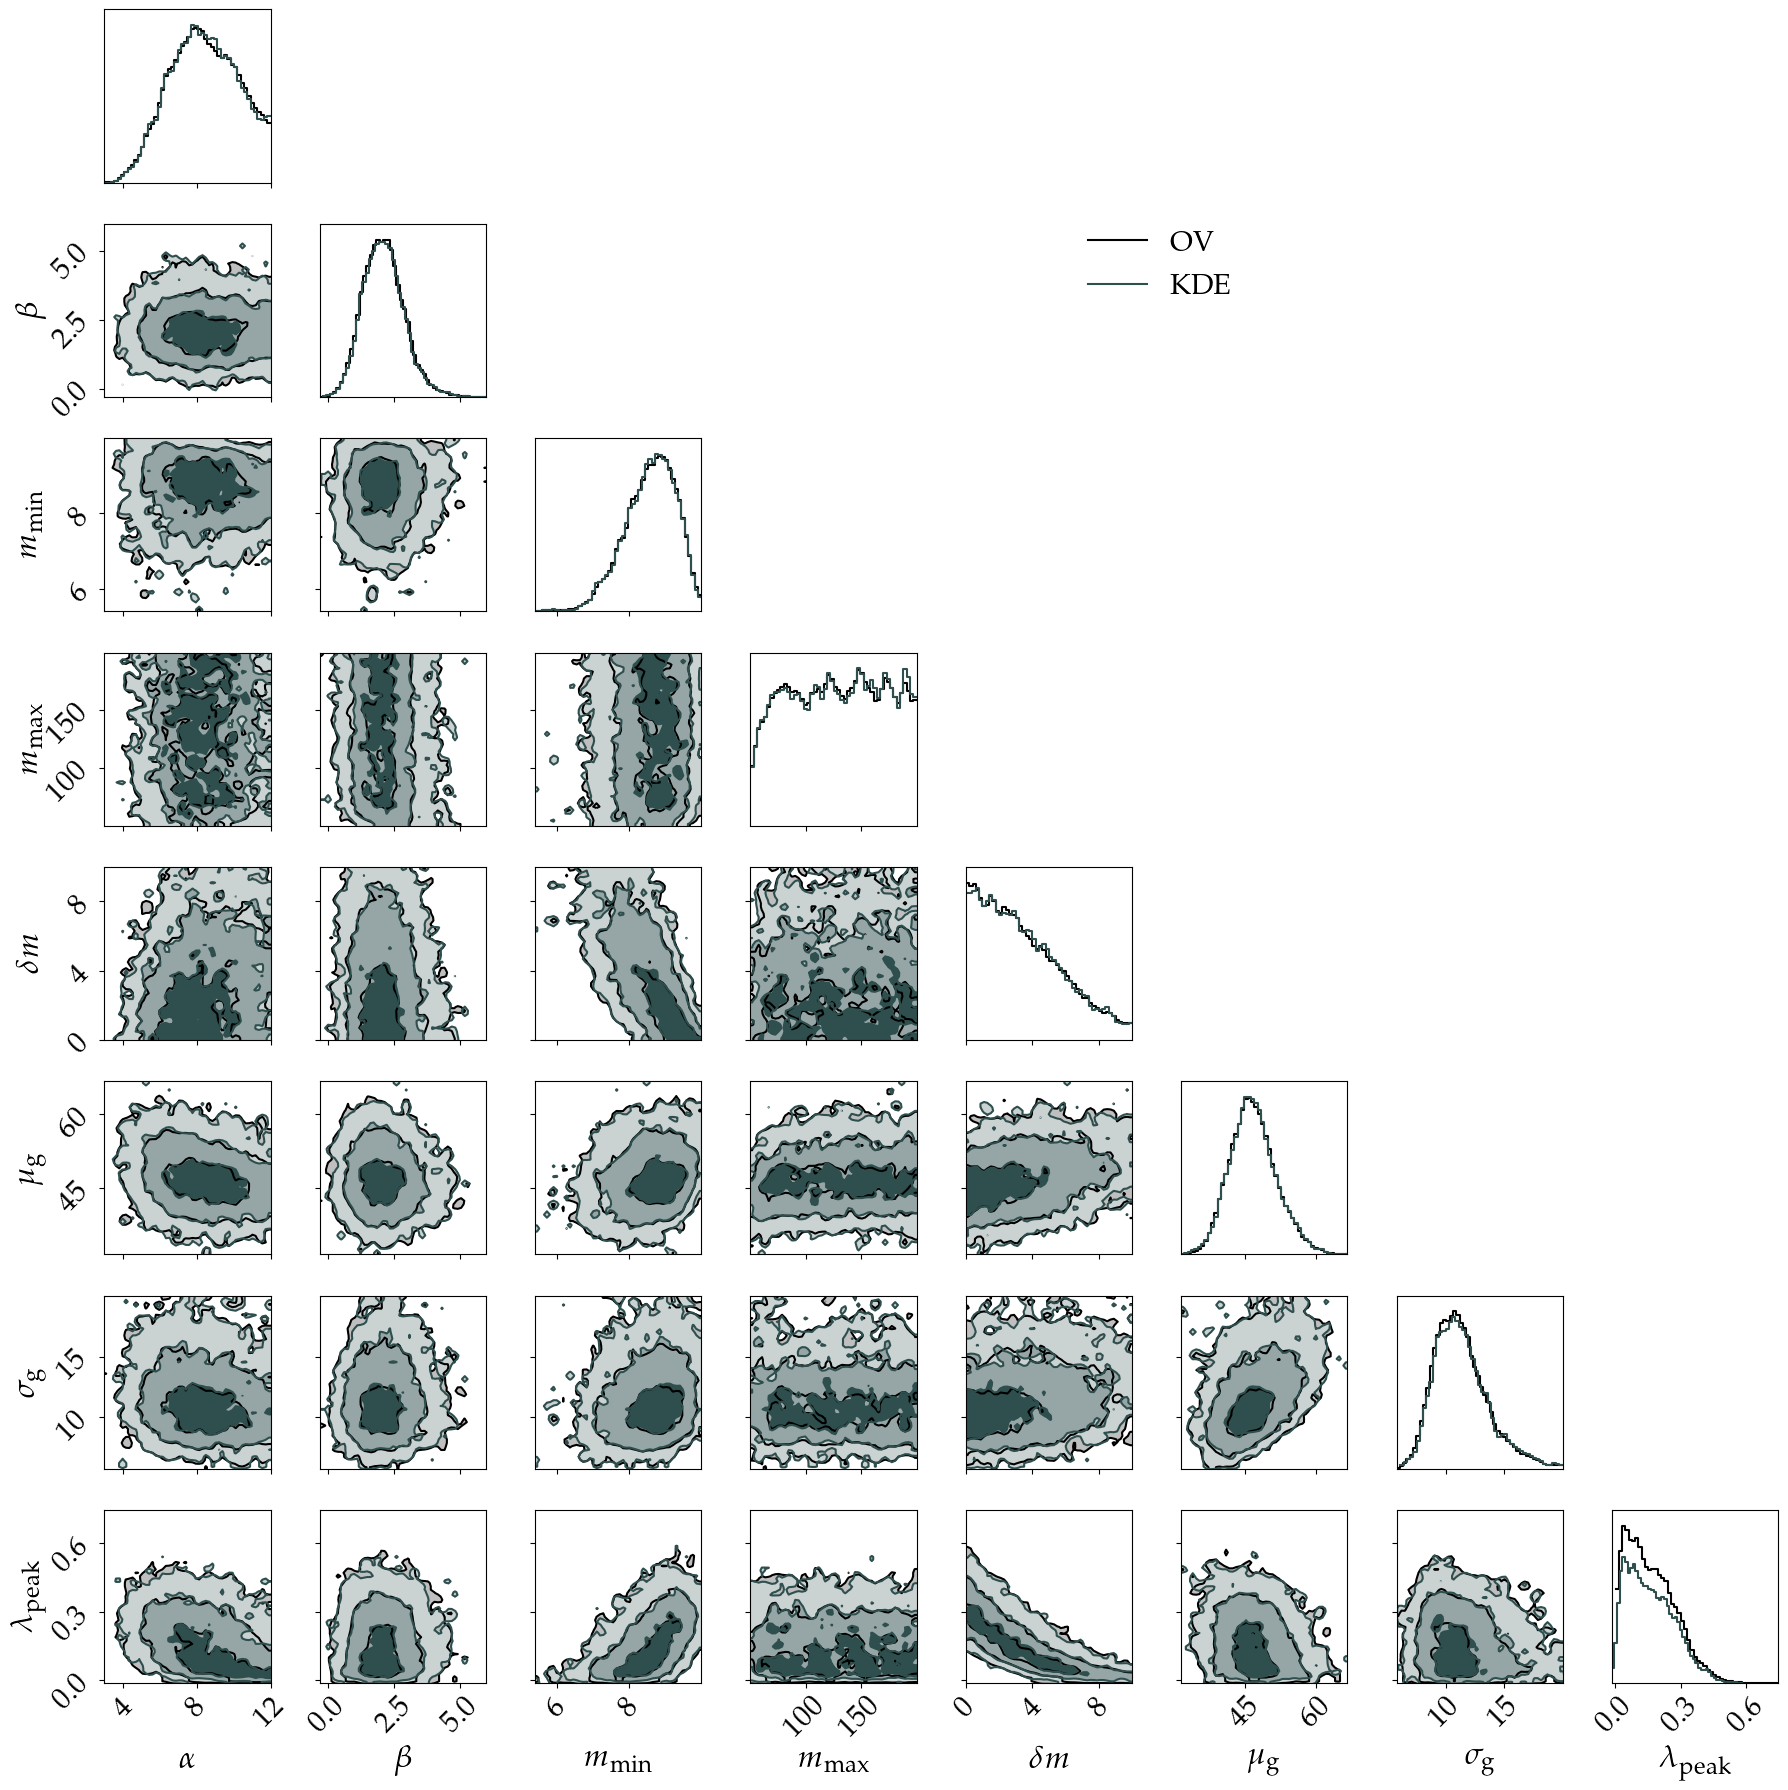

In [50]:
# compare corner plots as well
figure = corner.corner(mass_posteriors[red_mass_params], color = 'black', **default_kwargs)
corner.corner(kde_df, labels=red_mass_params_lbs, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.65, 0.85), fontsize = 21, frameon=False)
plt.tight_layout()
plt.show()

In [51]:
log_density = kde.score_samples(mass_posteriors)
density = np.exp(log_density)
mass_posteriors['density'] = density
df_sorted = mass_posteriors.sort_values('density', ascending=False)
df_sorted['cumulative_density'] = df_sorted['density'].cumsum()
total_density = df_sorted['density'].sum()
cutoff_density = 0.68 * total_density

/tmp/ipykernel_939766/2209789703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mass_posteriors['density'] = density


In [52]:
df_hdi_mass_z = df_sorted[df_sorted['cumulative_density'] <= cutoff_density]

In [53]:
df_hdi_mass_z

,alpha,beta,mmin,mmax,delta_m,mu_g,sigma_g,lambda_peak,density,cumulative_density
1924,10.243136,1.825121,7.890841,128.075425,2.236580,37.485108,12.415665,0.143929,9.626765e+08,9.626765e+08
2500,8.079255,1.781610,7.701436,128.017284,2.142782,37.146204,7.977583,0.289728,9.626765e+08,1.925353e+09
2419,8.738442,1.616272,8.584263,163.346440,2.833169,40.255130,12.608124,0.177790,9.626765e+08,2.888030e+09
1868,6.315670,2.551135,8.986322,128.106879,0.464306,39.624821,10.127135,0.240066,9.626765e+08,3.850706e+09
4975,7.631949,1.869245,9.281623,91.794842,1.605257,52.179407,11.365204,0.215938,9.626765e+08,4.813383e+09
...,...,...,...,...,...,...,...,...,...,...
182,9.209889,1.080860,8.565316,99.112706,3.647229,44.370750,14.752295,0.083423,9.626765e+08,4.358999e+12
104,6.228975,2.684373,7.478890,124.045985,5.494453,48.080964,19.974083,0.147975,9.626765e+08,4.359962e+12
195,6.568493,3.372486,8.338098,173.973664,3.021469,44.671164,15.607617,0.190450,9.626765e+08,4.360925e+12
205,9.713621,2.066593,8.955670,102.426467,8.960455,60.185450,14.437340,0.049283,9.626765e+08,4.361887e+12


In [93]:
from tqdm import tqdm

In [104]:
mm = np.linspace(8, 85, 50)
M1, M2 = np.meshgrid(mm,mm)

In [105]:
mass_wrap = icarogw.wrappers.massprior_PowerLawPeak()
mass_wrap=icarogw.wrappers.m1m2_conditioned_lowpass(mass_wrap)

In [106]:
n_posterior_samples = len(df_hdi_mass_z)
m1_prob, m2_prob = np.zeros((n_posterior_samples, len(mm))), np.zeros((n_posterior_samples, len(mm)))

In [107]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

100%|██████████| 4532/4532 [23:04<00:00,  3.27it/s]  


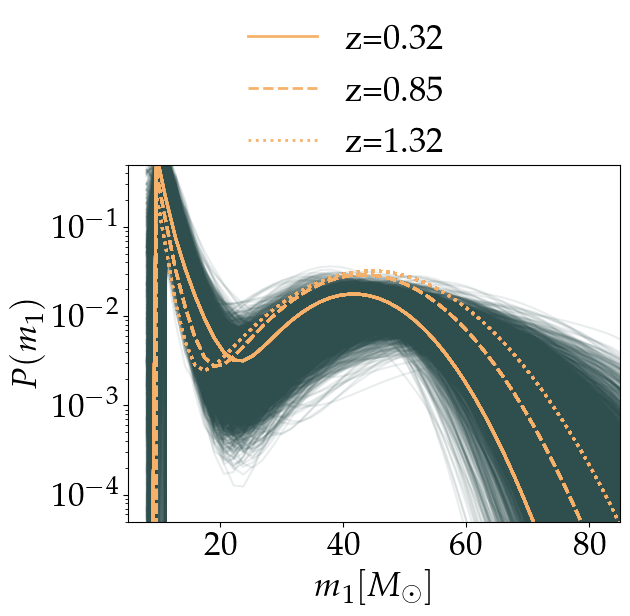

In [108]:
fig, ax = plt.subplots()

for i in tqdm(range(n_posterior_samples)):
    alpha = df_hdi_mass_z['alpha'].iloc[i]
    beta = df_hdi_mass_z['beta'].iloc[i]
    mmin = df_hdi_mass_z['mmin'].iloc[i]
    mmax = df_hdi_mass_z['mmax'].iloc[i]
    delta_m = df_hdi_mass_z['delta_m'].iloc[i]
    mu_g = df_hdi_mass_z['mu_g'].iloc[i]
    sigma_g = df_hdi_mass_z['sigma_g'].iloc[i]
    lambda_peak = df_hdi_mass_z['lambda_peak'].iloc[i]
    
    mass_wrap.update(**{'alpha':alpha,'beta':beta,'mmin':mmin,'mmax':mmax,'delta_m':delta_m,'mu_g':mu_g,'sigma_g':sigma_g,'lambda_peak':lambda_peak})
    pdf=mass_wrap.pdf(M1,M2)
    
    m1_prob[i, :] = np.trapz(pdf,mm,axis=0)
    m2_prob[i, :] = np.trapz(pdf,mm,axis=1)
    
    sns.lineplot(x = mm, y = m1_prob[i, :], color=my_color, alpha=0.1)
    
    my_z = 0.32 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob, color=my_color2, linestyle='solid', #label='z=%s' %my_z,
                linewidth=2, ax = ax)
    
    my_z = 0.85 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob,
                color=my_color2, linestyle='dashed', #label='z=%s' %my_z,
                linewidth=2, ax = ax)
    my_z = 1.32 
    mass_wrap.update(**{'alpha':alpha_z_inj(my_z),'beta':beta_z_inj(my_z),'mmin':mmin_z_inj(my_z),
                        'mmax':mmax_z_inj(my_z),'delta_m':delta_m_z(),'mu_g':mu_g_z_inj(my_z),
                        'sigma_g':sigma_g_z_inj(my_z),'lambda_peak':lambda_peak_z_inj(my_z)})
    pdf=mass_wrap.pdf(M1,M2)
    mass_prob = np.trapz(pdf,mm,axis=0)
    sns.lineplot(x = mm, y = mass_prob,
                color=my_color2, linestyle='dotted', #label='z=%s' %my_z,
                linewidth=2, ax = ax)
#mirror_lbs = [r'$z<0.65$', r'$0.65 \le z < 1.05$', r'$z\ge 1.05$']
#legend = ax.legend(title=mirror_lbs, title_fontsize=25, 
#                 frameon=False, loc='upper right')
    # Change label text color
#legend.get_title().set_color(my_color)
    
#ax.set_ylim(10**(-6), 1.5)
ax.set_ylim(5*10**(-5), 0.5)
ax.set_xlim(5, 85)
ax.set_yscale('log')
ax.set_xlabel('$m_1 [M_{\odot}]$', fontsize = 25)
ax.set_ylabel('$P(m_1)$', fontsize = 25)

# Create custom legend entries
custom_lines = [
    Line2D([0], [0], color=my_color2, linestyle='solid', lw=2), 
    Line2D([0], [0], color=my_color2, linestyle='dashed', lw=2),
    Line2D([0], [0], color=my_color2, linestyle='dotted', lw=2)  
]
fig.legend(custom_lines, ['z=0.32', 'z=0.85', 'z=1.32'], loc = 'center right', ncol = 1, 
            bbox_to_anchor = (0.75, 1.1), 
            fontsize = 25, frameon=False)


plt.subplots_adjust(top=0.05, 
                    bottom=0.01,
                    wspace=0.0, 
                    hspace=0.0)

plt.tight_layout()
plt.savefig(path_to_plots + '/' + 'redshift_mass_samples_hdi_icaro_no_binning_top.pdf', bbox_inches='tight')
plt.show()

## Vanilla case

In [72]:
# load dictionary of events
case1_dictionary_path = '/home/ulyana.dupletsa/MDC-Paper1/data/case1_events_dictionary.pkl'
with open(case1_dictionary_path, 'rb') as f:
    case1_dict = pickle.load(f)

In [73]:
case1_test_data = bilby.core.result.read_in_result(case1_dict['case1_inj_number']['case1_1e6inj_286ev'])
case1_test_data_posteriors = case1_test_data.posterior[columns_lbs]

### Rate plots

In [74]:
R0_vanilla = injected_values_vanilla['R0']
gamma_vanilla = injected_values_vanilla['gamma']
kappa_vanilla = injected_values_vanilla['kappa']
zp_vanilla = injected_values_vanilla['zp']

In [75]:
rate_posteriors_vanilla = case1_test_data_posteriors[['R0', 'gamma', 'zp', 'kappa']]

In [76]:
n_posterior_samples_vanilla = len(rate_posteriors_vanilla)

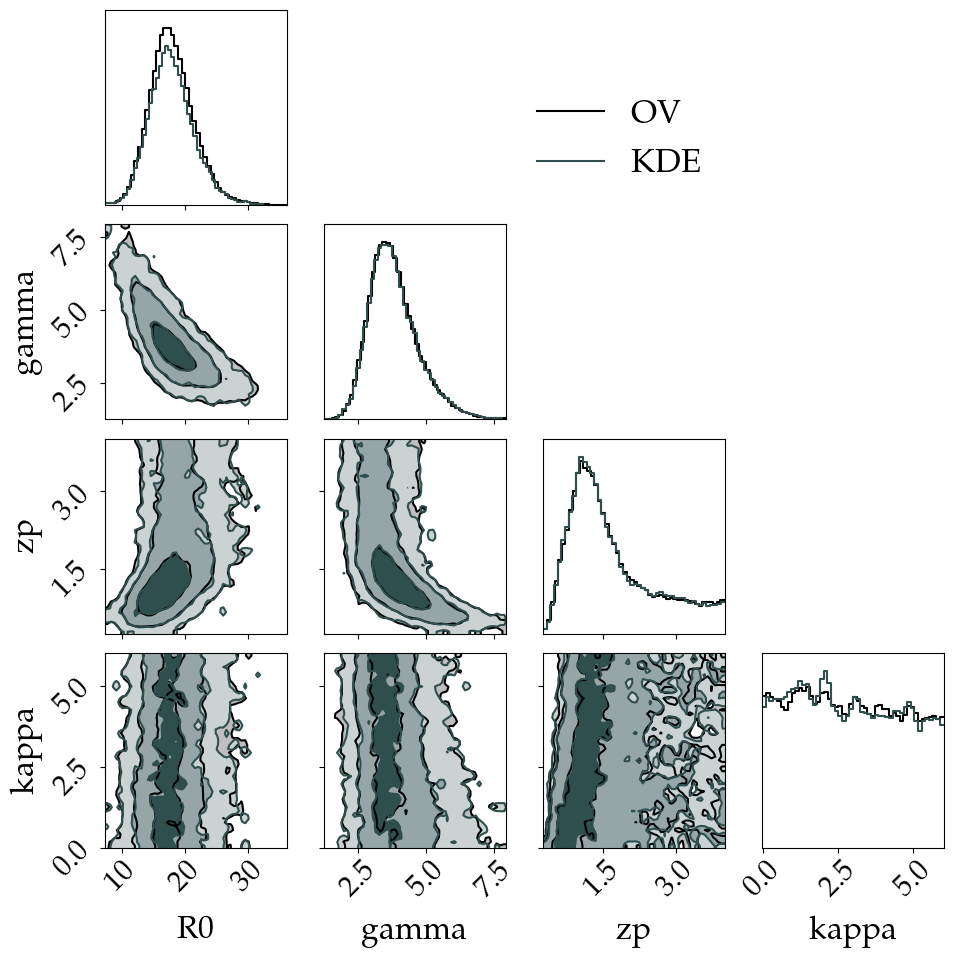

In [77]:
kde_van = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(rate_posteriors_vanilla)

np.random.seed(42)
kde_df_van = kde_van.sample(n_samples=len(rate_posteriors_vanilla))

# compare corner plots as well
figure = corner.corner(rate_posteriors_vanilla[rate_params], color = 'black', **default_kwargs)
corner.corner(kde_df_van, labels=rate_params, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 21)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.65, 0.85), fontsize = 24, frameon=False)
plt.tight_layout()
plt.show()

log_density = kde_van.score_samples(rate_posteriors_vanilla)
density = np.exp(log_density)
rate_posteriors_vanilla['density'] = density
df_van_sorted = rate_posteriors_vanilla.sort_values('density', ascending=False)
df_van_sorted['cumulative_density'] = df_van_sorted['density'].cumsum()
total_density = rate_posteriors_vanilla['density'].sum()
cutoff_density = 0.68 * total_density
df_hdi_van = df_van_sorted[df_van_sorted['cumulative_density'] <= cutoff_density]

100%|██████████| 5892/5892 [04:54<00:00, 20.03it/s]


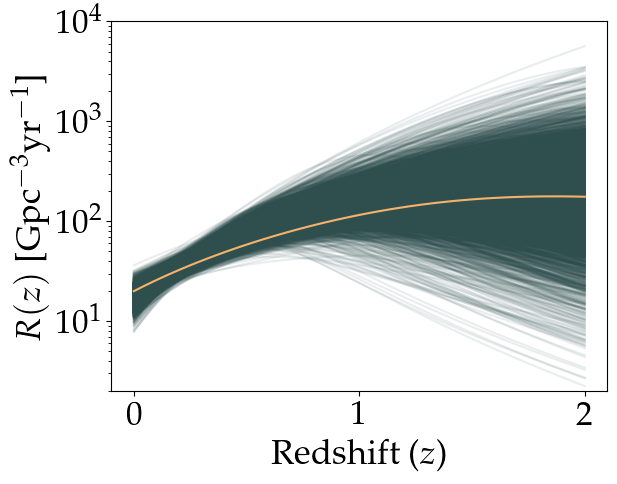

In [78]:
fig, ax = plt.subplots()
for i in tqdm(range(len(df_hdi_van))):
    R0_sample = df_hdi_van['R0'].iloc[i]
    gamma_sample = df_hdi_van['gamma'].iloc[i]
    zp_sample = df_hdi_van['zp'].iloc[i]
    kappa_sample = df_hdi_van['kappa'].iloc[i]
    sns.lineplot(x = zz, y = z_dependent_rate(zz, R0_sample, gamma_sample, zp_sample, kappa_sample),
             color=my_color, alpha=0.1)
    
sns.lineplot(x = zz, y = z_dependent_rate(zz, R0_vanilla, gamma_vanilla, zp_vanilla, kappa_vanilla),
         color=my_color2, linewidth=1.5)

plt.xlabel('Redshift ($z$)', fontsize = 25)
plt.ylabel('$R(z)$ [Gpc$^{-3}$yr$^{-1}$]', fontsize = 25) 
plt.yscale('log')
plt.ylim(2, 10**4)
plt.savefig(path_to_plots + '/' + 'vanilla_rate_samples_hdi.pdf', bbox_inches='tight')
plt.show()

### Mass plots

In [79]:
mm = np.linspace(5, 99, 50)

In [80]:
mass_params = ['alpha', 'beta', 'mmin', 'mmax', 'delta_m', 'mu_g', 'sigma_g', 'lambda_peak']

In [81]:
mass_model_vanilla_data = case1_test_data_posteriors[mass_params]

In [82]:
alpha_v_inj = injected_values_vanilla['alpha']
beta_v_inj = injected_values_vanilla['beta']
mmin_v_inj = injected_values_vanilla['mmin']
mmax_v_inj = injected_values_vanilla['mmax']
delta_m_v_inj = injected_values_vanilla['delta_m']
mu_g_v_inj = injected_values_vanilla['mu_g']
sigma_g_v_inj = injected_values_vanilla['sigma_g']
lambda_peak_v_inj = injected_values_vanilla['lambda_peak']

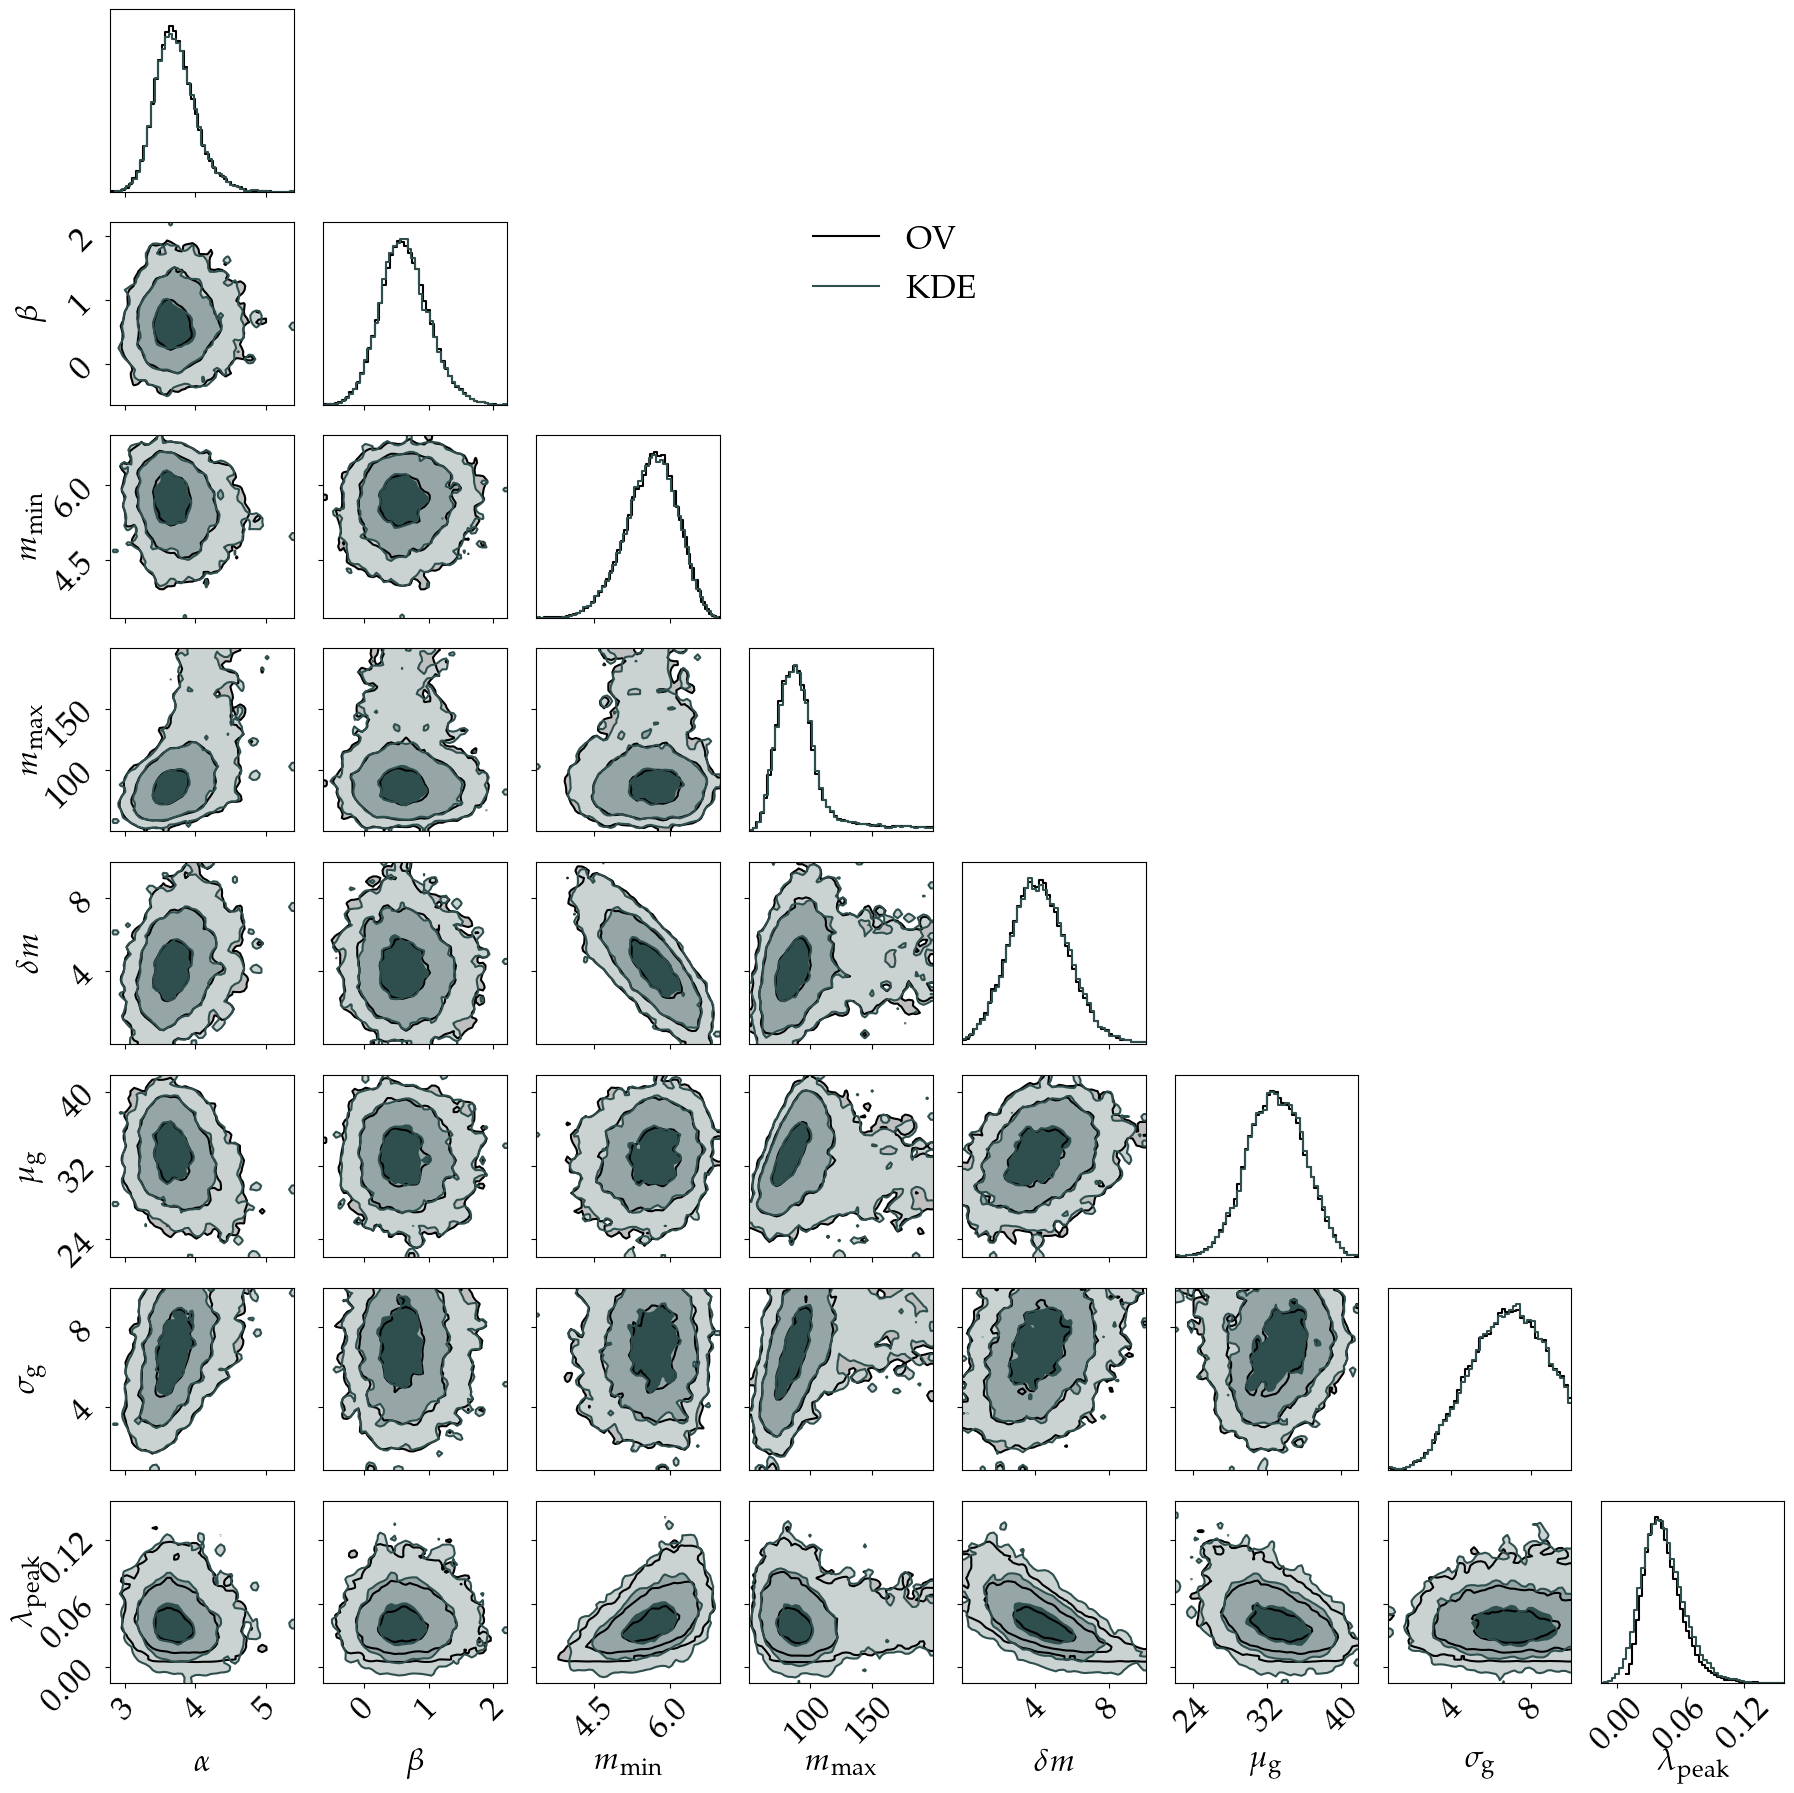

In [83]:
kde_mass_van = KernelDensity(kernel='gaussian', bandwidth=0.01).fit(mass_model_vanilla_data)

np.random.seed(11)
kde_df_mass_van = kde_mass_van.sample(n_samples=len(mass_model_vanilla_data))

# compare corner plots as well
figure = corner.corner(mass_model_vanilla_data[mass_params], color = 'black', **default_kwargs)
corner.corner(kde_df_mass_van, labels=red_mass_params_lbs, color = my_color, fig = figure, **default_kwargs)

for ax in figure.get_axes():
    ax.tick_params(axis = 'both', labelsize = 24)
    
figure.legend(['OV', 'KDE'], loc = 'center', ncol = 1, 
              bbox_to_anchor = (0.5, 0.85), fontsize = 24, frameon=False)
plt.tight_layout()
plt.show()

log_density = kde_mass_van.score_samples(mass_model_vanilla_data)
density = np.exp(log_density)
mass_model_vanilla_data['density'] = density
df_mass_van_sorted = mass_model_vanilla_data.sort_values('density', ascending=False)
df_mass_van_sorted['cumulative_density'] = df_mass_van_sorted['density'].cumsum()
total_density = mass_model_vanilla_data['density'].sum()
cutoff_density = 0.68 * total_density
df_hdi_mass_van = df_mass_van_sorted[df_mass_van_sorted['cumulative_density'] <= cutoff_density]

In [88]:
mm = np.linspace(5, 99, 50)
M1, M2 = np.meshgrid(mm,mm)

In [89]:
mass_wrap = icarogw.wrappers.massprior_PowerLawPeak()
mass_wrap=icarogw.wrappers.m1m2_conditioned_lowpass(mass_wrap)


n_posterior_samples = len(df_hdi_mass_van)
m1_prob, m2_prob  = np.zeros((n_posterior_samples, len(mm))), np.zeros((n_posterior_samples, len(mm)))

100%|██████████| 5892/5892 [05:12<00:00, 18.87it/s]


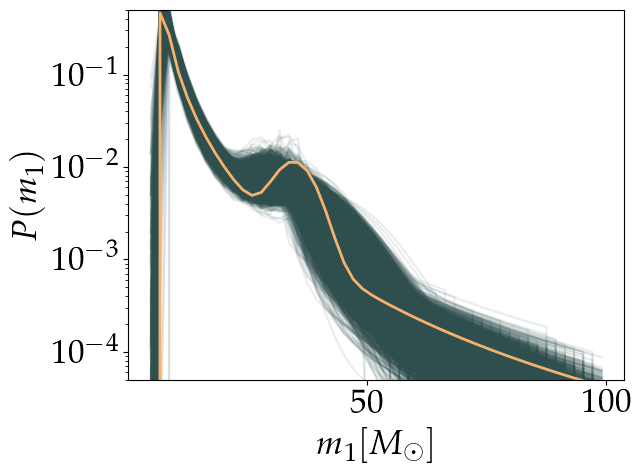

In [90]:
fig, ax = plt.subplots()

for i in tqdm(range(n_posterior_samples)):
    alpha = df_hdi_mass_van['alpha'].iloc[i]
    beta = df_hdi_mass_van['beta'].iloc[i]
    mmin = df_hdi_mass_van['mmin'].iloc[i]
    mmax = df_hdi_mass_van['mmax'].iloc[i]
    delta_m = df_hdi_mass_van['delta_m'].iloc[i]
    mu_g = df_hdi_mass_van['mu_g'].iloc[i]
    sigma_g = df_hdi_mass_van['sigma_g'].iloc[i]
    lambda_peak = df_hdi_mass_van['lambda_peak'].iloc[i]
    
    mass_wrap.update(**{'alpha':alpha,'beta':beta,'mmin':mmin,'mmax':mmax,'delta_m':delta_m,'mu_g':mu_g,'sigma_g':sigma_g,'lambda_peak':lambda_peak})
    pdf=mass_wrap.pdf(M1,M2)
    
    m1_prob[i, :] = np.trapz(pdf,mm,axis=0)
    m2_prob[i, :] = np.trapz(pdf,mm,axis=1)
    
    sns.lineplot(x = mm, y = m1_prob[i, :], color=my_color, alpha=0.1)

    
mass_wrap.update(**{'alpha':alpha_v_inj,'beta':beta_v_inj,'mmin':mmin_v_inj,'mmax':mmax_v_inj,
                    'delta_m':delta_m_v_inj,'mu_g':mu_g_v_inj,'sigma_g':sigma_g_v_inj,
                    'lambda_peak':lambda_peak_v_inj})
pdf=mass_wrap.pdf(M1,M2)   
m1_prob = np.trapz(pdf,mm,axis=0)
sns.lineplot(x = mm, y = m1_prob,
            color=my_color2, linestyle='solid',
            linewidth=2)

plt.xlabel('$m_1 [M_{\odot}]$', fontsize = 25)
plt.ylabel('$P(m_1)$', fontsize = 25)
plt.yscale('log')
plt.ylim(5*10**(-5), 0.5)
plt.savefig(path_to_plots + '/' + 'vanilla_mass_samples_hdi_icaro.pdf', bbox_inches='tight')
plt.show()